In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [2]:
olivetti = fetch_olivetti_faces(shuffle=True, random_state=42)

X = olivetti.data        # Features (pixel values)
y = olivetti.target     # Labels (person IDs)
images = olivetti.images


downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [3]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Number of classes:", len(np.unique(y)))


Feature shape: (400, 4096)
Target shape: (400,)
Number of classes: 40


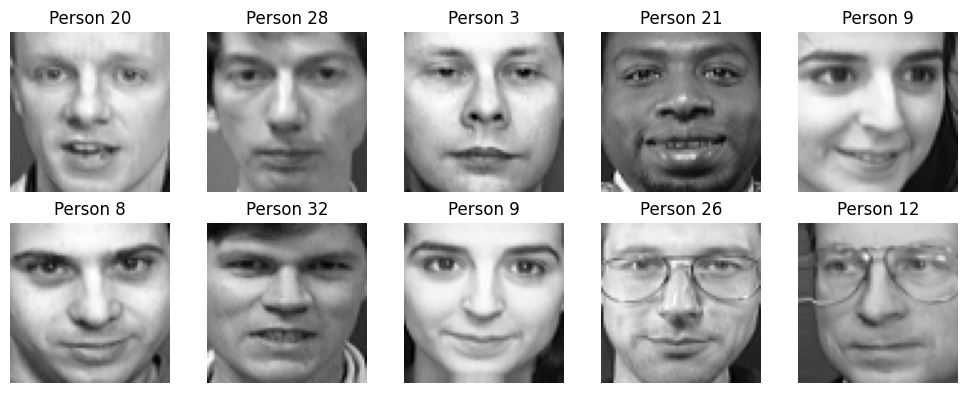

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, img, label in zip(axes.ravel(), images[:10], y[:10]):
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Person {label}")
    ax.axis('off')

plt.tight_layout()
plt.show()


In [5]:
print("Min pixel value:", X.min())
print("Max pixel value:", X.max())


Min pixel value: 0.0
Max pixel value: 1.0


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (300, 4096)
Testing samples: (100, 4096)


In [7]:
pca = PCA(n_components=150, whiten=True, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Reduced feature size:", X_train_pca.shape)


Reduced feature size: (300, 150)


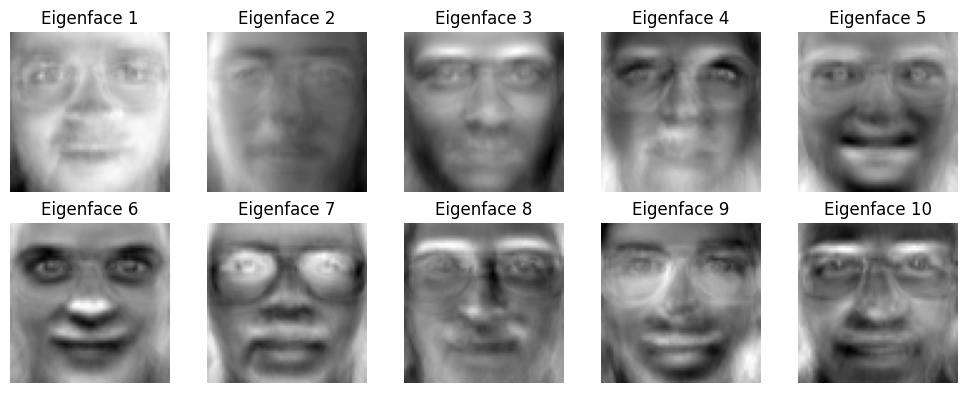

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(pca.components_[i].reshape(64, 64), cmap='gray')
    ax.set_title(f"Eigenface {i+1}")
    ax.axis('off')

plt.tight_layout()
plt.show()


In [9]:
print("Original features:", X.shape[1])
print("Reduced features after PCA:", X_train_pca.shape[1])


Original features: 4096
Reduced features after PCA: 150
